In [1]:
%load_ext watermark


In [2]:
import os
import subprocess

os.environ["POLARS_FORCE_NEW_STREAMING"] = "1"

from IPython.display import display, HTML
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from teeplot import teeplot as tp
from tqdm import tqdm

from pylib._calc_compsummary_stats import calc_compsummary_stats
from pylib._seed_global_rngs import seed_global_rngs


Covasim 3.1.6 (2024-01-28) — © 2020-2024 by IDM


In [3]:
%watermark -diwmuv -iv


Last updated: 2026-07-19T01:28:16.710513+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1062-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

polars : 1.29.0
numpy  : 2.1.2
seaborn: 0.13.2
pandas : 2.2.3
teeplot: 1.4.2

Watermark: 2.4.3



In [4]:
teeplot_subdir = "2025-05-19-compscreen-vanilla-summary"
teeplot_subdir


'2025-05-19-compscreen-vanilla-summary'

In [5]:
seed_global_rngs(1)


## Get Data


In [6]:
data_sources = {
    # "uk": "https://osf.io/mkjy5/download",
    # "multistrain": "https://osf.io/ywmpt/download",
    "vanilla": "https://osf.io/r8skg/download",
    # "vanilla-big": "https://osf.io/j4795/download",
    # "vanilla-big-1.3x": "https://osf.io/cnp5z/download",
}
tmp_path = f"/tmp/{teeplot_subdir}.pqt"


In [7]:
results = []

for source_name, url in data_sources.items():
    print(f"Downloading {source_name} data from {url}")

    subprocess.run(
        [
            "wget",
            "--tries=5",
            "--show-progress",
            "--progress=bar:force",
            "-O",
            str(tmp_path),
            url,
        ],
        check=True,
    )
    print("done!")

    df = pl.scan_parquet(
        tmp_path,
        low_memory=True,
        retries=5,
    )

    unique_groups = (
        df.unique(
            [
                "trt_name",
                "trt_n_downsample",
                "trt_hsurf_bits",
                "replicate_uuid",
            ]
        )
        .select(
            pl.col("trt_name"),
            pl.col("trt_n_downsample"),
            pl.col("trt_hsurf_bits"),
            pl.col("replicate_uuid"),
        )
        .drop_nans()
        .drop_nulls()
        .collect(engine="streaming")
    )

    for (trt_name, trt_n_downsample, trt_hsurf_bits, replicate_uuid) in tqdm(
        [*unique_groups.iter_rows()],
    ):
        group = df.filter(
            (pl.col("trt_name") == trt_name)
            & (pl.col("trt_n_downsample") == trt_n_downsample)
            & (pl.col("trt_hsurf_bits") == trt_hsurf_bits)
            & (pl.col("replicate_uuid") == replicate_uuid)
        ).collect(engine="streaming")

        for y in (
            "defmut_norm_all-num_leaves",
            # "defmut_norm_ot_bin:week-num_leaves",
            # "defmut_norm_ot_bin:fortnight-num_leaves",
            "defmut_norm_ot_bin:month-num_leaves",
            # "defmut_norm_ot_bin:quarter-num_leaves",
            # "defmut_norm_ot_bin:year-num_leaves",
            # "defmut_norm_match:variant_flavor-num_leaves",
            "defmut_norm_all-clade_duration",
            # "defmut_norm_ot_bin:week-clade_duration",
            # "defmut_norm_ot_bin:fortnight-clade_duration",
            "defmut_norm_ot_bin:month-clade_duration",
            # "defmut_norm_ot_bin:quarter-clade_duration",
            # "defmut_norm_ot_bin:year-clade_duration",
            # "defmut_norm_match:variant_flavor-clade_duration",
        ):
            res = calc_compsummary_stats(
                group.to_pandas(),
                x="is_focal_defmut",
                y=y,
            )
            results.extend(
                {
                    "source_name": source_name,
                    "trt_name": trt_name,
                    "trt_n_downsample": trt_n_downsample,
                    "trt_hsurf_bits": trt_hsurf_bits,
                    "replicate_uuid": replicate_uuid,
                    "y": y,
                    **record,
                }
                for record in res
            )


--2026-07-19 01:28:16--  https://osf.io/r8skg/download
Resolving osf.io (osf.io)... 35.190.84.173
Connecting to osf.io (osf.io)|35.190.84.173|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://osf.io/download/r8skg [following]
--2026-07-19 01:28:16--  https://osf.io/download/r8skg
Reusing existing connection to osf.io:443.
HTTP request sent, awaiting response... 308 Permanent Redirect
Location: https://osf.io/download/r8skg/ [following]
--2026-07-19 01:28:17--  https://osf.io/download/r8skg/
Reusing existing connection to osf.io:443.
HTTP request sent, awaiting response... 302 Found
Location: https://files.osf.io/v1/resources/37fv8/providers/osfstorage/682ca9f0110faab595b06ed7 [following]
--2026-07-19 01:28:17--  https://files.osf.io/v1/resources/37fv8/providers/osfstorage/682ca9f0110faab595b06ed7
Resolving files.osf.io (files.osf.io)... 35.186.214.196
Connecting to files.osf.io (files.osf.io)|35.186.214.196|:443... connected.
HTTP reques

done!


100%|██████████| 35/35 [03:15<00:00,  5.60s/it]


In [8]:
results_df = pd.DataFrame(results)
results_df


,source_name,trt_name,trt_n_downsample,trt_hsurf_bits,replicate_uuid,y,label,binom_n,binom_k,n,n_boot,p_boot,p_binom,p_mw,u_mw,cliffs_delta,na,n_grp
0,vanilla,Sben2x/Gdel2x,1000000,0,298b8490-3785-8872-b773-3ff0a790c147,defmut_norm_all-num_leaves,all,9762,6683,9762,10000,0.4970,5.048792e-01,NaN,NaN,NaN,0,9762
1,vanilla,Sben2x/Gdel2x,1000000,0,298b8490-3785-8872-b773-3ff0a790c147,defmut_norm_all-num_leaves,False,2991,1736,9762,10000,1.0000,1.000000e+00,5.411826e-73,12031300.0,0.188156,0,2991
2,vanilla,Sben2x/Gdel2x,1000000,0,298b8490-3785-8872-b773-3ff0a790c147,defmut_norm_all-num_leaves,True,6771,4947,9762,10000,0.0000,7.763543e-17,1.000000e+00,8220761.0,-0.188156,0,6771
3,vanilla,Sben2x/Gdel2x,1000000,0,298b8490-3785-8872-b773-3ff0a790c147,defmut_norm_ot_bin:month-num_leaves,all,9762,6683,9762,10000,0.4973,5.048792e-01,NaN,NaN,NaN,0,9762
4,vanilla,Sben2x/Gdel2x,1000000,0,298b8490-3785-8872-b773-3ff0a790c147,defmut_norm_ot_bin:month-num_leaves,False,2991,1736,9762,10000,1.0000,1.000000e+00,2.063043e-10,10926526.5,0.079053,0,2991
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
415,vanilla,Sben1.1x/Gneu,1000000,0,1c0ccc71-ce9d-8b98-8e89-603ca3204946,defmut_norm_all-clade_duration,False,3249,1909,3262,10000,0.4605,4.843274e-01,9.480136e-01,16198.0,-0.232995,0,3249
416,vanilla,Sben1.1x/Gneu,1000000,0,1c0ccc71-ce9d-8b98-8e89-603ca3204946,defmut_norm_all-clade_duration,True,13,6,3262,10000,0.9109,8.843418e-01,5.202152e-02,26039.0,0.232995,0,13
417,vanilla,Sben1.1x/Gneu,1000000,0,1c0ccc71-ce9d-8b98-8e89-603ca3204946,defmut_norm_ot_bin:month-clade_duration,all,3262,1922,3262,10000,0.4917,5.409610e-01,NaN,NaN,NaN,0,3262
418,vanilla,Sben1.1x/Gneu,1000000,0,1c0ccc71-ce9d-8b98-8e89-603ca3204946,defmut_norm_ot_bin:month-clade_duration,False,3249,1916,3262,10000,0.4586,5.173623e-01,9.342443e-01,16014.0,-0.241708,0,3249


In [9]:
results_df[results_df["label"] == True].groupby(  # noqa: E712
    ["trt_name", "trt_n_downsample", "trt_hsurf_bits", "y"]
).agg(
    {"n_grp": ["mean", "std"]},
)


n_grp  \
                                                                                             mean   
trt_name          trt_n_downsample trt_hsurf_bits y                                                 
Sben1.1x/Gdel1.1x 1000000          0              defmut_norm_all-clade_duration             18.4   
                                                  defmut_norm_all-num_leaves                 18.4   
                                                  defmut_norm_ot_bin:month-clade_duration    18.4   
                                                  defmut_norm_ot_bin:month-num_leaves        18.4   
Sben1.1x/Gneu     1000000          0              defmut_norm_all-clade_duration             21.2   
                                                  defmut_norm_all-num_leaves                 21.2   
                                                  defmut_norm_ot_bin:month-clade_duration    21.2   
                                                  defmut_norm_ot_bin:month-num_leaves        21.2   
Sben1.3x/Gdel1.3x 1000000          0              defmut_norm_all-clade_duration            361.4   
                                                  defmut_norm_all-num_leaves                361.4   
                                                  defmut_norm_ot_bin:month-clade_duration   361.4   
                                                  defmut_norm_ot_bin:month-num_leaves       361.4   
Sben1.3x/Gneu     1000000          0              defmut_norm_all-clade_duration            465.6   
                                                  defmut_norm_all-num_leaves                465.6   
                                                  defmut_norm_ot_bin:month-clade_duration   465.6   
                                                  defmut_norm_ot_bin:month-num_leaves       465.6   
Sben2x/Gdel2x     1000000          0              defmut_norm_all-clade_duration           6679.0   
                                                  defmut_norm_all-num_leaves               6679.0   
                                                  defmut_norm_ot_bin:month-clade_duration  6679.0   
                                                  defmut_norm_ot_bin:month-num_leaves      6679.0   
Sben2x/Gneu       1000000          0              defmut_norm_all-clade_duration           8493.2   
                                                  defmut_norm_all-num_leaves               8493.2   
                                                  defmut_norm_ot_bin:month-clade_duration  8493.2   
                                                  defmut_norm_ot_bin:month-num_leaves      8493.2   
Sneu/Gneu         1000000          0              defmut_norm_all-clade_duration             14.8   
                                                  defmut_norm_all-num_leaves                 14.8   
                                                  defmut_norm_ot_bin:month-clade_duration    14.8   
                                                  defmut_norm_ot_bin:month-num_leaves        14.8   

                                                                                                       
                                                                                                  std  
trt_name          trt_n_downsample trt_hsurf_bits y                                                    
Sben1.1x/Gdel1.1x 1000000          0              defmut_norm_all-clade_duration             4.159327  
                                                  defmut_norm_all-num_leaves                 4.159327  
                                                  defmut_norm_ot_bin:month-clade_duration    4.159327  
                                                  defmut_norm_ot_bin:month-num_leaves        4.159327  
Sben1.1x/Gneu     1000000          0              defmut_norm_all-clade_duration             5.630275  
                                                  defmut_norm_all-num_leaves                 5.630275  
                        

In [10]:
results_df["y"] = results_df["y"].str.removeprefix("defmut_norm_all-")
results_df["y"] = results_df["y"].str.removeprefix("defmut_norm_ot_bin:")
results_df["y"] = results_df["y"].str.removeprefix("defmut_norm_match:")
results_df["y"] = results_df["y"].str.replace("-", "\n")
results_df["y"] = results_df["y"].str.replace("_", " ")

results_df["label"] = results_df["label"].astype(str)
results_df["label"] = results_df["label"].str.replace("False", "bkgnd")
results_df["label"] = results_df["label"].str.replace("True", "focal")

results_df["trt_name_"] = results_df["trt_name"].str.replace("/", "\n")


teeplots/2025-05-19-compscreen-vanilla-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=y+viz=catplot+x=smallsamp+y=p-boot+ext=.pdf
teeplots/2025-05-19-compscreen-vanilla-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=y+viz=catplot+x=smallsamp+y=p-boot+ext=.png


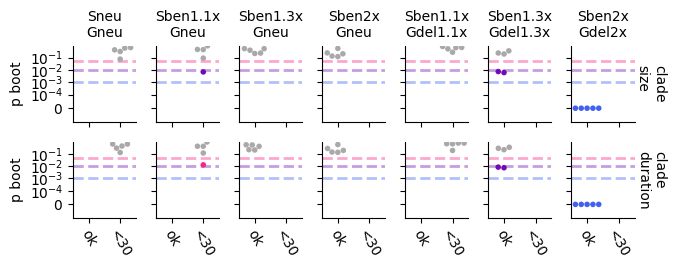

teeplots/2025-05-19-compscreen-vanilla-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=y+viz=catplot+x=smallsamp+y=p-binom+ext=.pdf
teeplots/2025-05-19-compscreen-vanilla-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=y+viz=catplot+x=smallsamp+y=p-binom+ext=.png


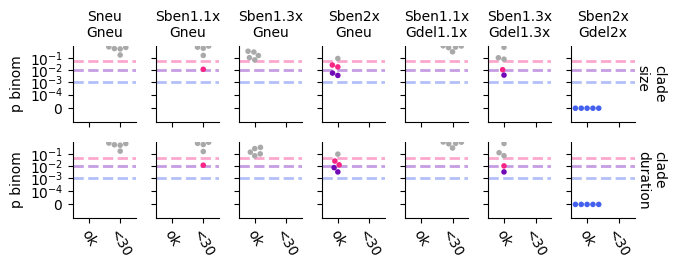

teeplots/2025-05-19-compscreen-vanilla-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=y+viz=catplot+x=smallsamp+y=p-mw+ext=.pdf
teeplots/2025-05-19-compscreen-vanilla-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=y+viz=catplot+x=smallsamp+y=p-mw+ext=.png


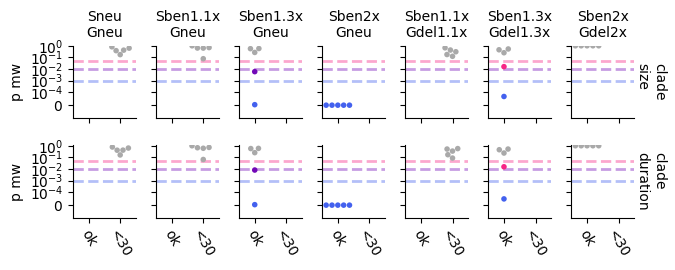

In [11]:
bins = [-np.inf, 0.001, 0.01, 0.05, np.inf]
labels = ["<0.001", "<0.01", "<0.05", "ns"]
gentle_palette = ["#4361EE", "#7209B7", "#F72585", "#A9A9A9"]

for y in "p_boot", "p_binom", "p_mw":
    display(HTML(f"<h1>{y=}</h1>"))

    data = results_df[
        (results_df["trt_hsurf_bits"] == 0)
        & (
            results_df["trt_n_downsample"]
            == results_df["trt_n_downsample"].max()
        )
        & (results_df["label"] != "all")
    ].copy()
    data["sig"] = pd.cut(
        data[y],
        bins=bins,
        labels=labels,
        include_lowest=True,
    )
    data["sig"] = data["sig"].cat.set_categories(labels, ordered=True)
    data["smallsamp"] = data["n_grp"] < 30
    data["smallsamp"] = data["smallsamp"].map({True: "<30", False: "ok"})
    data["y_"] = (
        data["y"]
        .str.replace("month\n", "")
        .str.replace("num leaves", "clade\nsize")
        .str.replace("clade duration", "clade\nduration")
    )
    col_order = filter(
        set(data["trt_name_"]).__contains__,
        [
            "Sneu\nGneu",
            "Sben1.1x\nGneu",
            "Sben1.3x\nGneu",
            "Sben2x\nGneu",
            "Sben1.1x\nGdel1.1x",
            "Sben1.3x\nGdel1.3x",
            "Sben2x\nGdel2x",
        ],
    )
    col_order = [*col_order]
    with tp.teed(
        sns.catplot,
        data=data[
            data["y"].str.startswith("month").values
            & (data["label"] == "focal")
        ],
        y=y,
        col="trt_name_",
        row="y_",
        hue="sig",
        x="smallsamp",
        col_order=col_order,
        legend=False,
        kind="swarm",
        margin_titles=True,
        height=1.4,
        aspect=0.7,
        size=4,
        palette=gentle_palette,
        teeplot_outattrs={"comparator": "month"},
        teeplot_subdir=teeplot_subdir,
    ) as teed:

        teed.set_titles(col_template="{col_name}", row_template="{row_name}")
        for ax in teed.axes.flat:
            ax.set_yscale("symlog", linthresh=0.0001)
            ax.set_ylim(-0.0001, None)
            ax.axhline(
                0.05,
                alpha=0.4,
                color=gentle_palette[2],
                linestyle="--",
                linewidth=2,
            )
            ax.axhline(
                0.01,
                alpha=0.4,
                color=gentle_palette[1],
                linestyle="--",
                linewidth=2,
            )
            ax.axhline(
                0.001,
                alpha=0.4,
                color=gentle_palette[0],
                linestyle="--",
                linewidth=2,
            )
            ax.tick_params(axis="x", rotation=-60)
            ax.set_xlabel("")
            ax.set_ylabel(y.replace("_", " "))

        teed.tight_layout()


teeplots/2025-05-19-compscreen-vanilla-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-boot+ext=.pdf
teeplots/2025-05-19-compscreen-vanilla-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-boot+ext=.png


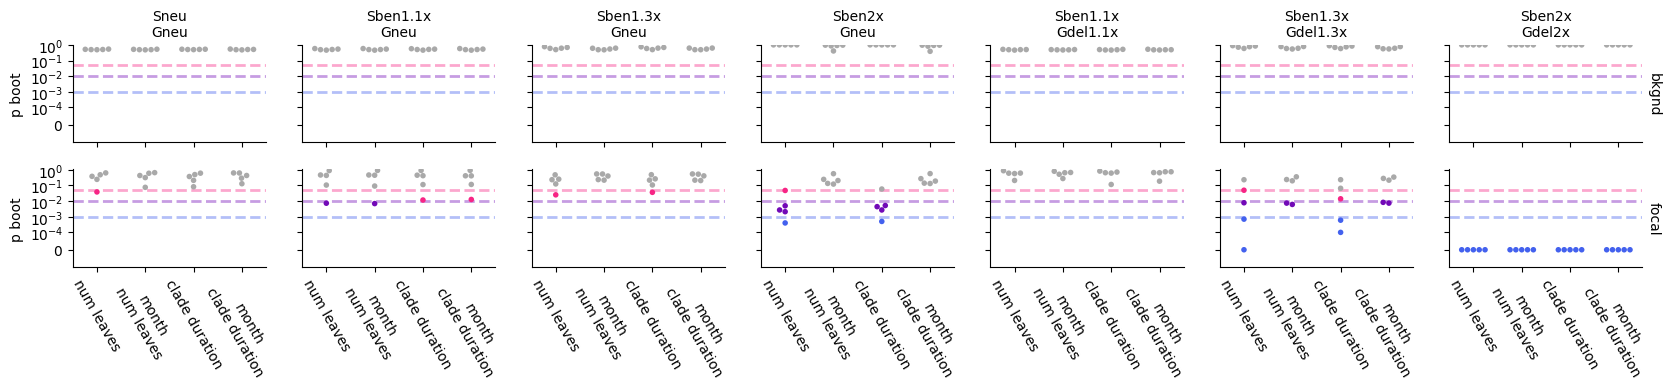

teeplots/2025-05-19-compscreen-vanilla-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-boot+ext=.pdf
teeplots/2025-05-19-compscreen-vanilla-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-boot+ext=.png


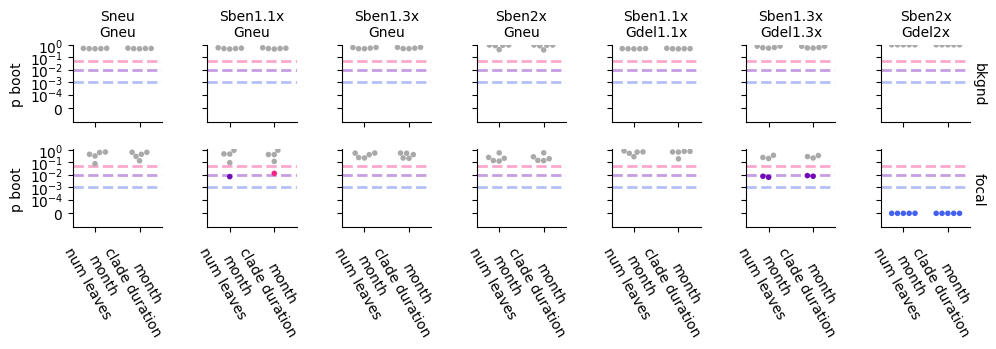

teeplots/2025-05-19-compscreen-vanilla-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-binom+ext=.pdf
teeplots/2025-05-19-compscreen-vanilla-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-binom+ext=.png


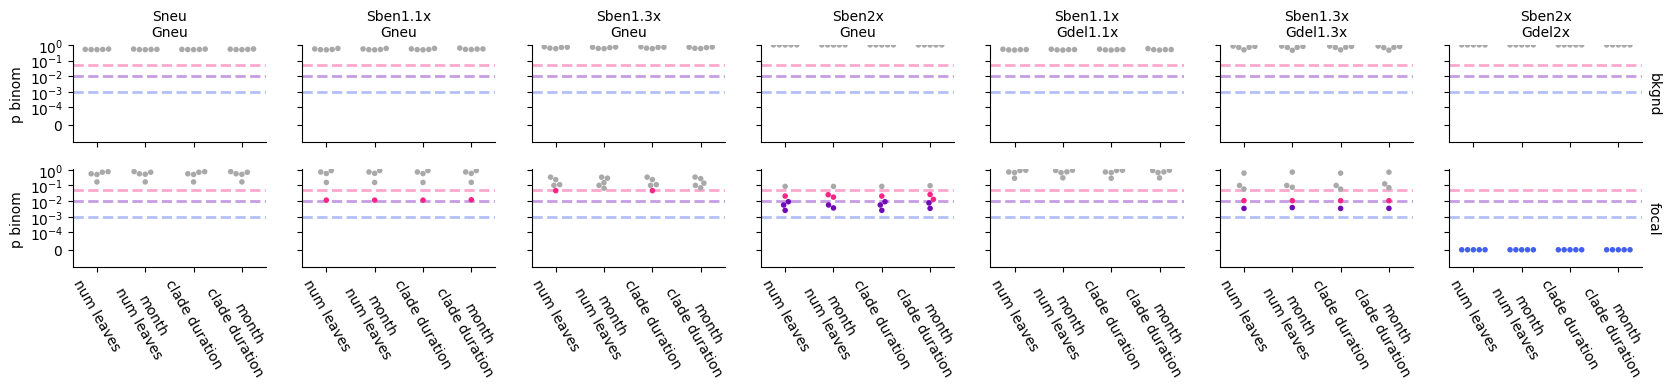

teeplots/2025-05-19-compscreen-vanilla-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-binom+ext=.pdf
teeplots/2025-05-19-compscreen-vanilla-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-binom+ext=.png


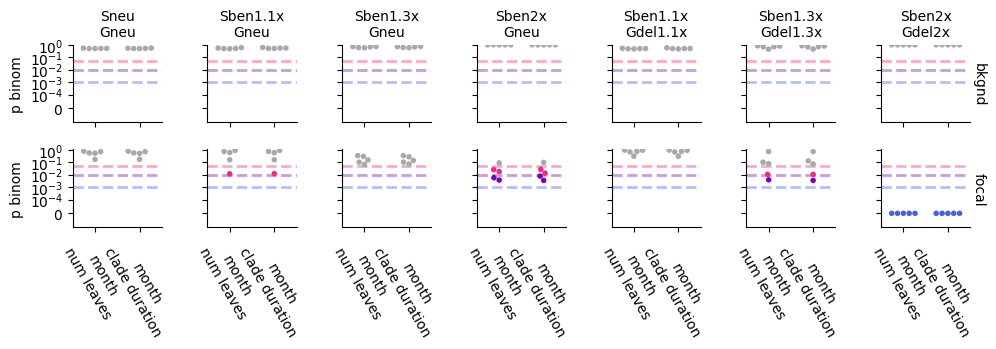

teeplots/2025-05-19-compscreen-vanilla-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-mw+ext=.pdf
teeplots/2025-05-19-compscreen-vanilla-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-mw+ext=.png


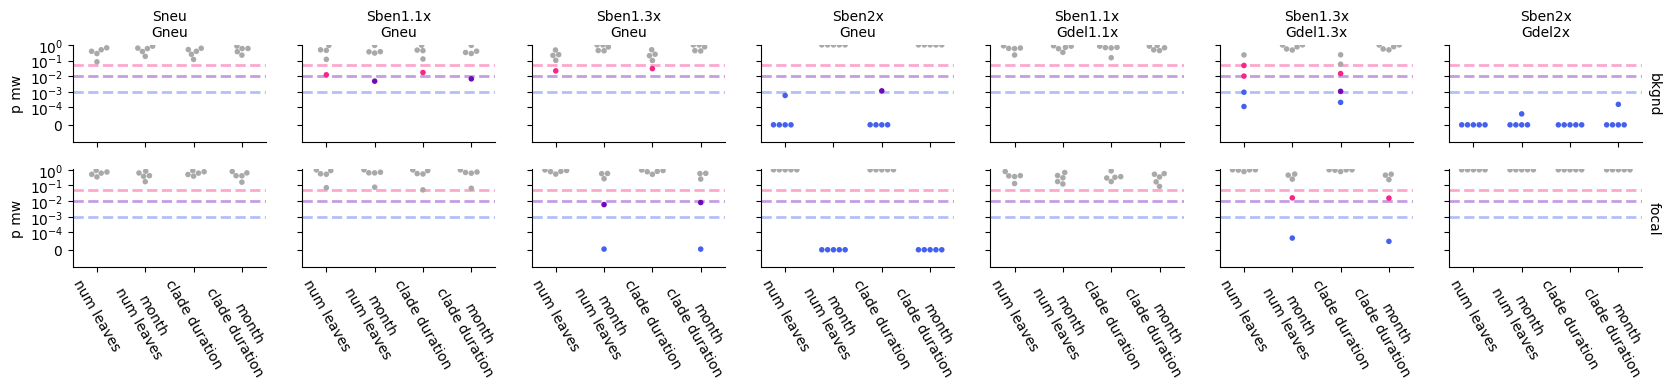

teeplots/2025-05-19-compscreen-vanilla-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-mw+ext=.pdf
teeplots/2025-05-19-compscreen-vanilla-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-mw+ext=.png


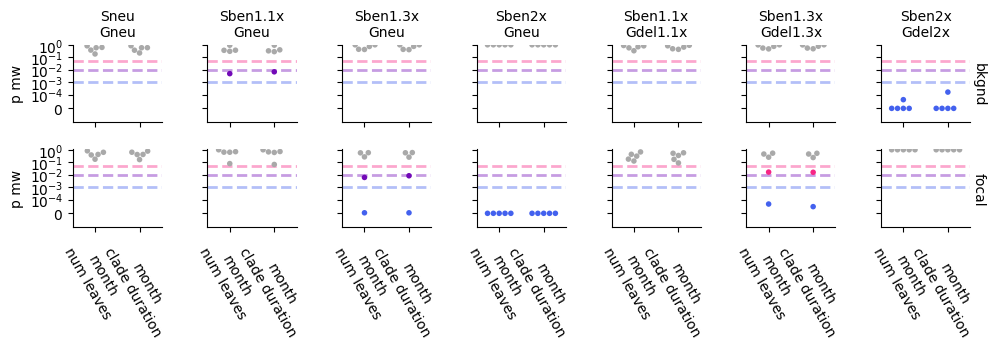

teeplots/2025-05-19-compscreen-vanilla-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=u-mw+ext=.pdf
teeplots/2025-05-19-compscreen-vanilla-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=u-mw+ext=.png


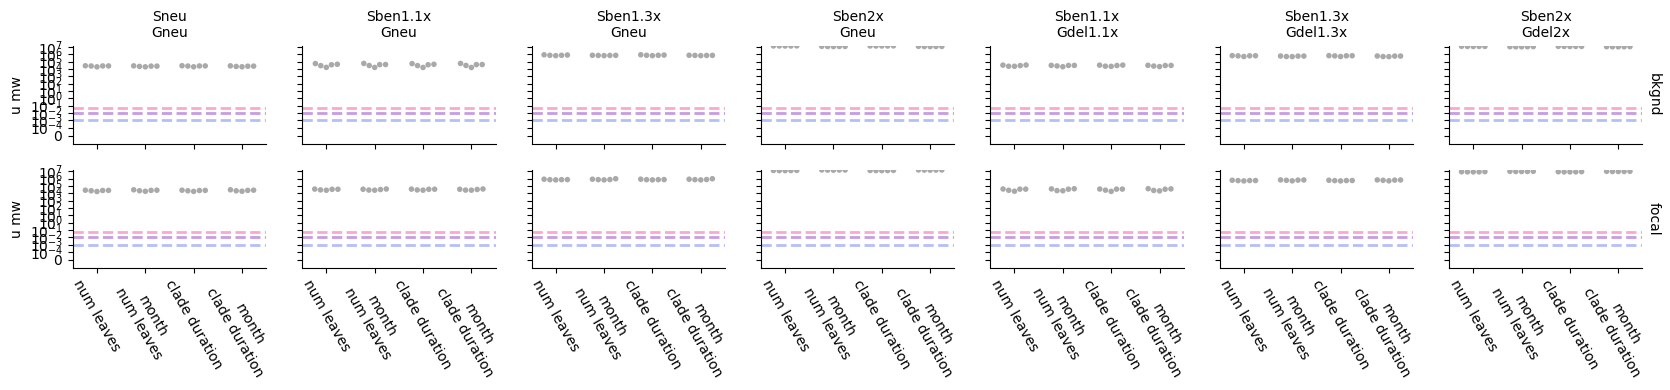

teeplots/2025-05-19-compscreen-vanilla-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=u-mw+ext=.pdf
teeplots/2025-05-19-compscreen-vanilla-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=u-mw+ext=.png


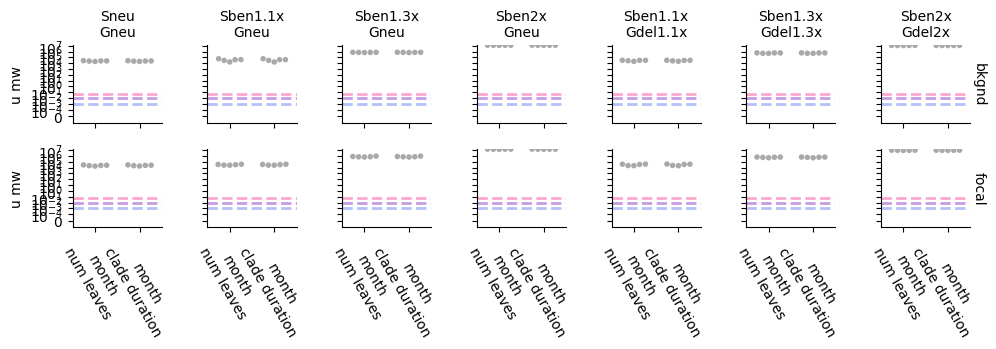

teeplots/2025-05-19-compscreen-vanilla-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=cliffs-delta+ext=.pdf
teeplots/2025-05-19-compscreen-vanilla-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=cliffs-delta+ext=.png


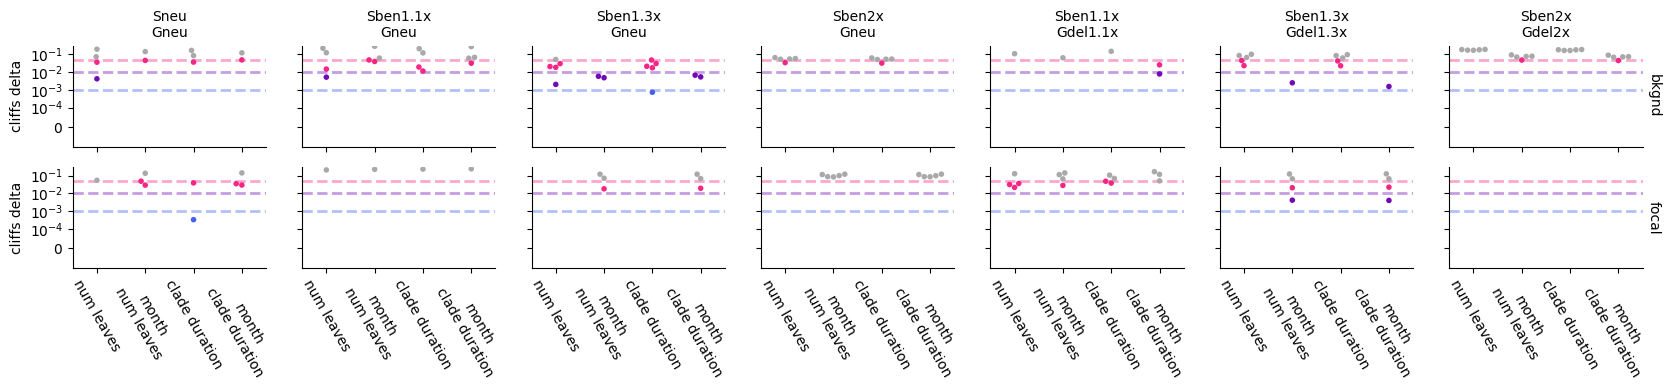

teeplots/2025-05-19-compscreen-vanilla-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=cliffs-delta+ext=.pdf
teeplots/2025-05-19-compscreen-vanilla-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=cliffs-delta+ext=.png


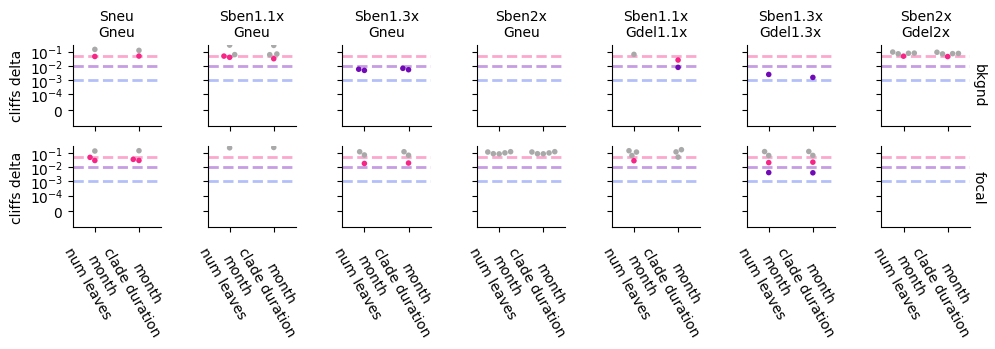

In [12]:
bins = [-np.inf, 0.001, 0.01, 0.05, np.inf]
labels = ["<0.001", "<0.01", "<0.05", "ns"]
gentle_palette = ["#4361EE", "#7209B7", "#F72585", "#A9A9A9"]

for y in "p_boot", "p_binom", "p_mw", "u_mw", "cliffs_delta":
    display(HTML(f"<h1>{y=}</h1>"))

    data = results_df[
        (results_df["trt_hsurf_bits"] == 0)
        & (
            results_df["trt_n_downsample"]
            == results_df["trt_n_downsample"].max()
        )
        & (results_df["label"] != "all")
    ].copy()
    data["sig"] = pd.cut(
        data[y],
        bins=bins,
        labels=labels,
        include_lowest=True,
    )
    data["sig"] = data["sig"].cat.set_categories(labels, ordered=True)
    col_order = filter(
        set(data["trt_name_"]).__contains__,
        [
            "Sneu\nGneu",
            "Sben1.1x\nGneu",
            "Sben1.3x\nGneu",
            "Sben2x\nGneu",
            "Sben1.1x\nGdel1.1x",
            "Sben1.3x\nGdel1.3x",
            "Sben2x\nGdel2x",
        ],
    )
    col_order = [*col_order]
    with tp.teed(
        sns.catplot,
        data=data,
        y=y,
        x="y",
        col="trt_name_",
        row="label",
        hue="sig",
        col_order=col_order,
        legend=False,
        kind="swarm",
        margin_titles=True,
        height=2,
        aspect=1.2,
        size=4,
        palette=gentle_palette,
        teeplot_subdir=teeplot_subdir,
    ) as teed:
        teed.set_titles(col_template="{col_name}", row_template="{row_name}")
        for ax in teed.axes.flat:
            ax.set_yscale("symlog", linthresh=0.0001)
            ax.set_ylim(-0.0001, None)
            ax.axhline(
                0.05,
                alpha=0.4,
                color=gentle_palette[2],
                linestyle="--",
                linewidth=2,
            )
            ax.axhline(
                0.01,
                alpha=0.4,
                color=gentle_palette[1],
                linestyle="--",
                linewidth=2,
            )
            ax.axhline(
                0.001,
                alpha=0.4,
                color=gentle_palette[0],
                linestyle="--",
                linewidth=2,
            )
            ax.tick_params(axis="x", rotation=-60)
            ax.set_xlabel("")
            ax.set_ylabel(y.replace("_", " "))

        teed.tight_layout()

    with tp.teed(
        sns.catplot,
        data=data[data["y"].str.startswith("month").values],
        y=y,
        x="y",
        col="trt_name_",
        row="label",
        hue="sig",
        col_order=col_order,
        legend=False,
        kind="swarm",
        margin_titles=True,
        height=1.8,
        aspect=0.8,
        size=4,
        palette=gentle_palette,
        teeplot_outattrs={"comparator": "month"},
        teeplot_subdir=teeplot_subdir,
    ) as teed:
        teed.set_titles(col_template="{col_name}", row_template="{row_name}")
        for ax in teed.axes.flat:
            ax.set_yscale("symlog", linthresh=0.0001)
            ax.set_ylim(-0.0001, None)
            ax.axhline(
                0.05,
                alpha=0.4,
                color=gentle_palette[2],
                linestyle="--",
                linewidth=2,
            )
            ax.axhline(
                0.01,
                alpha=0.4,
                color=gentle_palette[1],
                linestyle="--",
                linewidth=2,
            )
            ax.axhline(
                0.001,
                alpha=0.4,
                color=gentle_palette[0],
                linestyle="--",
                linewidth=2,
            )
            ax.tick_params(axis="x", rotation=-60)
            ax.set_xlabel("")
            ax.set_ylabel(y.replace("_", " "))

        teed.tight_layout()
